# 03 — Unsupervised Learning: Clustering & Visualization
**Owner:** team · **Status:** after 01 / aligned with notebooks/02_classifiers.ipynb

## What this notebook does
- Loads train/val/test from `data/processed/`
- Same text cleaning as notebook 02
- TF-IDF: fit on train `cleaned_text` only; transform val & test (same vocabulary)
- Truncated SVD (LSA): fit on train TF-IDF only; transform val & test → `Z_train`, `Z_val`, `Z_test` for clustering / t-SNE
- Optional Ekman multi-label arrays `y_*` for later metrics (ARI/NMI), not for fitting unsupervised steps

## Input files (pull from repo)
- `data/processed/train.csv`, `val.csv`, `test.csv`

## Figures (after clustering cells are added)
- `report/figures/tsne_clusters.png`, `report/figures/tsne_true_labels.png`

## How to run
Run from **`notebooks/`**. Top-to-bottom. t-SNE is slow — subsample (~5000 rows) later.

In [5]:
# Import libraries
from pathlib import Path

import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import re
from better_profanity import profanity
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer

# Download NLTK resources (run once)
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

# Load splits from data/processed (run notebook from notebooks/ so ROOT resolves like 01_data_prep)
ROOT = Path("..")
PROCESSED_DIR = ROOT / "data" / "processed"

train_df = pd.read_csv(PROCESSED_DIR / "train.csv")
val_df = pd.read_csv(PROCESSED_DIR / "val.csv")
test_df = pd.read_csv(PROCESSED_DIR / "test.csv")

print(f"Loaded CSVs from {PROCESSED_DIR.resolve()}")
print(f"train: {train_df.shape} | val: {val_df.shape} | test: {test_df.shape}")

[nltk_data] Downloading package stopwords to /Users/kaffe/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/kaffe/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /Users/kaffe/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Loaded CSVs from /Users/kaffe/kaffe‘code/KTH_course/DM1590/EmotionRadar/data/processed
train: (43410, 8) | val: (5426, 8) | test: (5427, 8)


In [6]:
# ----------------------
# Text Preprocessing
# ----------------------
# Initialize tools
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()
profanity.load_censor_words()


def preprocess_text(text):
    # 1. Convert to lowercase
    text = text.lower()
    # 2. Remove URLs (Reddit links)
    text = re.sub(r"http\S+|www\S+|https\S+", "", text, flags=re.MULTILINE)
    # 3. Remove special characters, numbers, and extra spaces
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    # 4. Tokenize, remove stopwords, and lemmatize
    tokens = text.split()
    tokens = [
        lemmatizer.lemmatize(token)
        for token in tokens
        if token not in stop_words and len(token) > 2
    ]

    # drop profane tokens
    # -------------DISSCUSSION-------------
    # maybe we shouldn't filter out profanity, because it represent some emotions like anger，disappointment
    # tokens = [t for t in tokens if not profanity.contains_profanity(t)]
    # -------------DISSCUSSION-------------

    # 5. Join tokens back to text
    return " ".join(tokens)


for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    df["cleaned_text"] = df["text"].apply(preprocess_text)

print("Preprocessing done for train, val, test.")
print(f"  train: {len(train_df)} rows | val: {len(val_df)} rows | test: {len(test_df)} rows")

label_cols = [c for c in train_df.columns if c not in ("text", "cleaned_text")]
print("\nSample (train):")
print(train_df[["text", "cleaned_text"] + label_cols].head(3))

Preprocessing done for train, val, test.
  train: 43410 rows | val: 5426 rows | test: 5427 rows

Sample (train):
                                                text  \
0  My favourite food is anything I didn't have to...   
1  Now if he does off himself, everyone will thin...   
2                     WHY THE FUCK IS BAYLESS ISOING   

                                        cleaned_text  anger  disgust  fear  \
0                 favourite food anything didnt cook      0        0     0   
1  everyone think he laugh screwing people instea...      0        0     0   
2                                fuck bayless isoing      1        0     0   

   joy  sadness  surprise  neutral  
0    0        0         0        1  
1    0        0         0        1  
2    0        0         0        0  


In [7]:
# ----------------------
# TF-IDF Vectorization
# ----------------------
# Fit on train only; transform val/test with the same vocabulary (no leakage).
label_cols = [c for c in train_df.columns if c not in ("text", "cleaned_text")]

tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english",
    ngram_range=(1, 2),
)

X_train = tfidf_vectorizer.fit_transform(train_df["cleaned_text"])
X_val = tfidf_vectorizer.transform(val_df["cleaned_text"])
X_test = tfidf_vectorizer.transform(test_df["cleaned_text"])

y_train = train_df[label_cols].to_numpy()
y_val = val_df[label_cols].to_numpy()
y_test = test_df[label_cols].to_numpy()

print(f"Vocabulary size: {len(tfidf_vectorizer.vocabulary_)}")
print(f"X_train: {X_train.shape} (sparse) | y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape} (sparse) | y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape} (sparse) | y_test:  {y_test.shape}")
print(f"Labels ({len(label_cols)}): {label_cols}")

Vocabulary size: 5000
X_train: (43410, 5000) (sparse) | y_train: (43410, 7)
X_val:   (5426, 5000) (sparse) | y_val:   (5426, 7)
X_test:  (5427, 5000) (sparse) | y_test:  (5427, 7)
Labels (7): ['anger', 'disgust', 'fear', 'joy', 'sadness', 'surprise', 'neutral']


  (plot) 50% variance: not reached within k=500 (max cumulative = 48.93%)


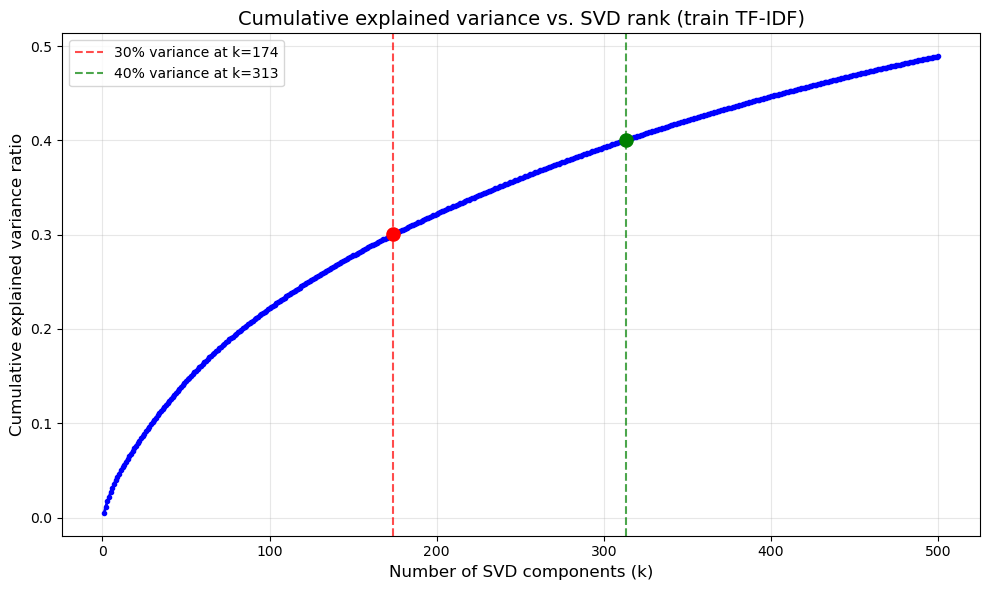


=== Dimension hints (train only) ===
  - 30% variance: k = 174
  - 40% variance: k = 313
  - 50% variance: not reached within k=500

Cumulative variance at k=100: 22.21%

Chosen n_components=174 (smallest k with ≥30% train variance; rank cap=4999).


In [ ]:
# ----------------------
# Truncated SVD — variance curve 
# ----------------------
# Fit a high-rank SVD on X_train only (diagnostic curve; same split discipline as notebook 02).


def smallest_k_at_least_variance(cumulative, thresh):
    """Return smallest k such that cumulative[k-1] >= thresh, or None if never reached."""
    for idx, var in enumerate(cumulative):
        if var >= thresh:
            return idx + 1
    return None


max_rank = min(500, X_train.shape[0] - 1, X_train.shape[1] - 1)
svd_for_analysis = TruncatedSVD(n_components=max_rank, random_state=42)
svd_for_analysis.fit(X_train)

cumulative_variance = svd_for_analysis.explained_variance_ratio_.cumsum()

plt.figure(figsize=(10, 6))
plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o",
    linestyle="-",
    color="b",
    linewidth=2,
    markersize=3,
)

thresholds = [0.30, 0.40, 0.50]
colors = ["r", "g", "orange"]
labels_thresh = ["30% variance", "40% variance", "50% variance"]

for thresh, color, lbl in zip(thresholds, colors, labels_thresh):
    dim = smallest_k_at_least_variance(cumulative_variance, thresh)
    if dim is None:
        print(
            f"  (plot) {lbl}: not reached within k={max_rank} "
            f"(max cumulative = {cumulative_variance[-1]:.2%})"
        )
        continue
    plt.axvline(x=dim, color=color, linestyle="--", alpha=0.7, label=f"{lbl} at k={dim}")
    plt.scatter(dim, cumulative_variance[dim - 1], color=color, s=90, zorder=5)

plt.title("Cumulative explained variance vs. SVD rank (train TF-IDF)", fontsize=14)
plt.xlabel("Number of SVD components (k)", fontsize=12)
plt.ylabel("Cumulative explained variance ratio", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

print("\n=== Dimension hints (train only) ===")
for thresh, lbl in zip(thresholds, labels_thresh):
    dim = smallest_k_at_least_variance(cumulative_variance, thresh)
    if dim is None:
        print(f"  - {lbl}: not reached within k={max_rank}")
    else:
        print(f"  - {lbl}: k = {dim}")
if len(cumulative_variance) >= 100:
    print(f"\nCumulative variance at k=100: {cumulative_variance[99]:.2%}")

# Choose k for embeddings: aim for ≥30% on train (fallback = max_rank cap if unreachable)
# n_svd_components
var_target = 0.30
n_svd_max = min(X_train.shape[0] - 1, X_train.shape[1] - 1)
k_for_target = smallest_k_at_least_variance(cumulative_variance, var_target)
if k_for_target is None:
    n_svd_components = int(min(max_rank, n_svd_max))
    print(
        f"\nChosen n_components={n_svd_components} "
        f"({var_target:.0%} variance not reached in k≤{max_rank}; using analysis cap)."
    )
else:
    n_svd_components = int(min(k_for_target, n_svd_max))
    print(
        f"\nChosen n_components={n_svd_components} "
        f"(smallest k with ≥{var_target:.0%} train variance; rank cap={n_svd_max})."
    )

In [9]:
# ----------------------
# Truncated SVD — embeddings for clustering / t-SNE
# ----------------------
# Fit SVD rank on train only; transform val and test with the same subspace.

svd_embedder = TruncatedSVD(n_components=n_svd_components, random_state=42)

Z_train = svd_embedder.fit_transform(X_train)
Z_val = svd_embedder.transform(X_val)
Z_test = svd_embedder.transform(X_test)

explained_total = float(svd_embedder.explained_variance_ratio_.sum())
print("\nLSA embeddings (dense)")
print(f"  Z_train: {Z_train.shape} | Z_val: {Z_val.shape} | Z_test: {Z_test.shape}")
print(f"Variance explained by these {n_svd_components} components (train): ~{explained_total:.2%}")
print("\nDone — ready for k-means / t-SNE downstream.")


LSA embeddings (dense)
  Z_train: (43410, 174) | Z_val: (5426, 174) | Z_test: (5427, 174)
Variance explained by these 174 components (train): ~29.84%

Done — ready for k-means / t-SNE downstream.
